In [7]:
%load_ext autoreload
%autoreload 2

!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [1]:
# import torch
# torch.cuda.empty_cache()

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')
dl = dm.train_dataloader()

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all_missing
INFO     | _get_names | Track & Cam : MOO02_hand_puncher_2 cam0
INFO     | _get_names | Track & Cam : MOO02_hand_puncher_2 cam1
INFO     | _get_names | Track & Cam : MOO03_hand_shooter_easy cam0
INFO     | _get_names | Track & Cam : MOO03_hand_shooter_easy cam1
INFO     | _get_names | Track & Cam : MOO04_hand_shooter_hard cam0
INFO     | _get_names | Track & Cam : MOO04_hand_shooter_hard cam1
INFO     | _get_names | Track & Cam : MOO05_inspect_easy cam0
INFO     | _get_names | Track & Cam : MOO05_inspect_easy cam1
INFO     | _get_names | Track & Cam : MOO06_inspect_hard cam0
INFO     | _get_names | Track & Cam : MOO06_inspect_hard cam1
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam0
INFO     | _get_names | Track & Cam : MOO07_mapping_easy cam1
INFO     | _get_names | Track & Cam : MOO08_mapping_hard cam0
INFO     | _get_names | Track & Cam : MOO08_mapping_hard cam1
INFO     | _get_name

In [4]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences, cert = batch

print(f'{ref_patches.shape}')
print(f'{ref_keypoints.shape}')
print(f'{tar_patches.shape}')
print(f'{tar_keypoints.shape}')
print(f'{confidences.shape}')
print(f'{cert.shape}')

torch.Size([10, 1, 82, 82])
torch.Size([10, 2])
torch.Size([10, 1, 82, 82])
torch.Size([10, 2])
torch.Size([10])
torch.Size([10, 1, 82, 82])


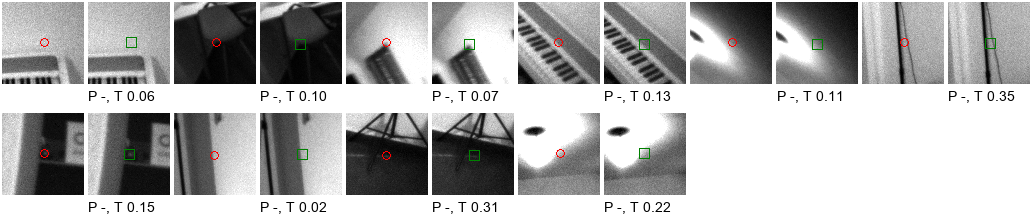

In [12]:
batch = next(iter(dl))
ref_patches, ref_keypoints, tar_patches, tar_keypoints, confidences, cert = batch

# print(f'{ref_keypoints[:10]=}')

count = 24 * 2

show_batch(
    ref_patches, tar_patches,
    ref_keypoints, tar_keypoints,
    tar_keypoints,

    confidences_true=confidences,
    
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

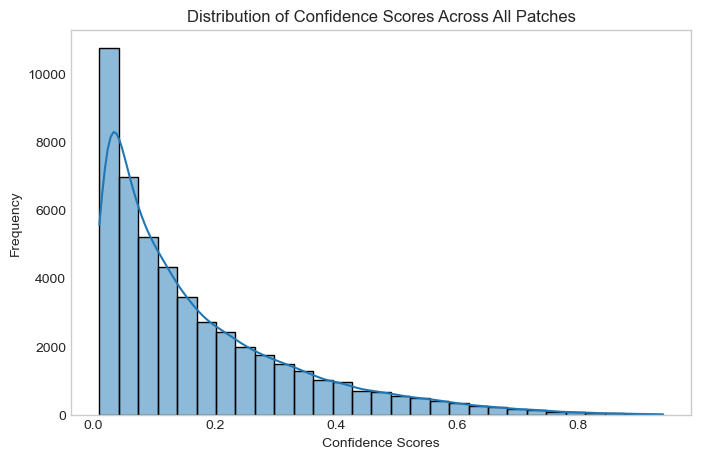

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_confidence_distribution(dataloader, N=None):
    all_confidences = []
    
    for i, batch in enumerate(dataloader):
        if N is not None and i >= N:
            break
        _, _, _, _, confidences, _ = batch
        all_confidences.extend(confidences.cpu().numpy())
    
    all_confidences = np.array(all_confidences)
    
    # Adjust for skewed distribution by equalizing bins
    min_conf, max_conf = all_confidences.min(), all_confidences.max()
    bins = np.linspace(min_conf, max_conf, 30)
    
    plt.figure(figsize=(8, 5))
    sns.histplot(all_confidences, bins=bins, kde=True)
    plt.xlabel("Confidence Scores")
    plt.ylabel("Frequency")
    plt.title("Distribution of Confidence Scores Across All Patches")
    plt.grid()
    plt.show()


dl = dm.train_dataloader()
plot_confidence_distribution(dl)

In [8]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _ = batch
        
#         # Convert to NumPy array
#         confidences = confidences.cpu().numpy()

#         # Keep high-confidence values, randomly sample low-confidence ones
#         for conf in confidences:
#             if conf > 0.1:  # Always keep high confidence
#                 all_confidences.append(conf)
#             # elif np.random.rand() < conf:  # Lower confidence, lower probability of adding
#             #     all_confidences.append(conf)

#     all_confidences = np.array(all_confidences)
    
#     # Adjust for skewed distribution by equalizing bins
#     min_conf, max_conf = all_confidences.min(), all_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 30)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(all_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Adjusted Distribution of Confidence Scores Across All Batches")
#     plt.grid()
#     plt.show()


# dl = dm.train_dataloader()
# plot_confidence_distribution(dl)

In [9]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# def plot_confidence_distribution(dataloader, N=None, low_conf_fraction=0.5):
#     all_confidences = []
    
#     for i, batch in enumerate(dataloader):
#         if N is not None and i >= N:
#             break
#         _, _, _, _, confidences, _ = batch
#         all_confidences.extend(confidences.cpu().numpy())
    
#     all_confidences = np.array(all_confidences)
    
#     # Reduce patches with lower confidence scores
#     median_conf = np.median(all_confidences)
#     low_conf = all_confidences[all_confidences < median_conf]
#     high_conf = all_confidences[all_confidences >= median_conf]
    
#     # Downsample low-confidence scores
#     low_conf = np.random.choice(low_conf, size=int(len(low_conf) * low_conf_fraction), replace=False)
    
#     balanced_confidences = np.concatenate([low_conf, high_conf])
    
#     # Adjust bins based on new distribution
#     min_conf, max_conf = balanced_confidences.min(), balanced_confidences.max()
#     bins = np.linspace(min_conf, max_conf, 10)
    
#     plt.figure(figsize=(8, 5))
#     sns.histplot(balanced_confidences, bins=bins, kde=True)
#     plt.xlabel("Confidence Scores")
#     plt.ylabel("Frequency")
#     plt.title("Balanced Distribution of Confidence Scores Across All Batches")
#     plt.grid()
#     plt.show()

# # Example usage
# dl = dm.train_dataloader()
# plot_confidence_distribution(dl, low_conf_fraction=0.01)


# Light

In [8]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

11,539,075


In [9]:
target_coords, target_confidences = light(
    ref_patches, 
    tar_patches, 
    ref_keypoints
)

# target_confidences = F.sigmoid(target_confidences)

print(f'{target_coords.shape=}')
print(f'{target_confidences.shape=}')

target_coords.shape=torch.Size([10, 2])
target_confidences.shape=torch.Size([10, 1])
